# FINN — Features-Informed Neural Network

**Four feature sets, one question:** how much does each set of symmetry descriptors contribute to binding-energy prediction?

| Label | Features | Physics |
|---|---|---|
| **LDM** | $Z,\,N,\,A^{2/3},\,T_z$ | Liquid-drop / Bethe–Weizsäcker macroscopic inputs |
| **LDM+SU(4)** | LDM + $\mathcal{C}_2,\mathcal{C}_4[\mathrm{SU}(4)]$ | Adds Wigner spin–isospin supermultiplet symmetry |
| **LDM+SU(3)** | LDM + $N_{\hbar\omega},\mathcal{C}_2,\mathcal{C}_3[\mathrm{SU}(3)]$ | Adds shell structure and deformation |
| **LDM+SU(4)+SU(3)** | LDM + $\mathcal{C}_2,\mathcal{C}_4[\mathrm{SU}(4)]$ + $N_{\hbar\omega},\mathcal{C}_2,\mathcal{C}_3[\mathrm{SU}(3)]$ | Adds shell structure, deformation and supermultiplet |

Each feature set is trained with a physics-informed loss, equal to the standard mean-squared error on binding energy plus Garvey–Kelson physics-informed regularisation.

## 1 — Imports

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve().parent))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import symass
from symass import Normalizer, SOAP, build_gk_indices, train, train_pinn, evaluate

torch.manual_seed(42)
np.random.seed(42)

/Users/phongdang/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2 — Data

Load nuclear masses, filtered to $Z \geq 8$, $N \geq 8$, and add $A^{2/3}$ as a derived column.

In [3]:
df = symass.load_dataframe(keep_extrapolated=False, Zmin=8, Nmin=8)
df['A_23'] = df['A'].astype(float) ** (2/3)   # surface-term proxy

# ── Four feature sets ────────────────────────────────────────────────────────
FEATURE_SETS = {
    'LDM'            : ['Z', 'N', 'A_23', 'T_z'],
    'LDM+SU(4)'      : ['Z', 'N', 'A_23', 'T_z', 'C2_4', 'C4_4'],
    'LDM+SU(4)+SU(3)': ['Z', 'N', 'A_23', 'T_z', 'C2_4', 'C4_4', 'Nhw', 'C2_3', 'C3_3'],
    'LDM+SU(3)'      : ['Z', 'N', 'A_23', 'T_z', 'Nhw', 'C2_3', 'C3_3'],
}

TARGET = 'BE_total_MeV'
y_all  = df[TARGET].to_numpy(dtype=np.float32).reshape(-1, 1)
N_all  = df['N'].to_numpy(dtype=int)
Z_all  = df['Z'].to_numpy(dtype=int)
ame_source = df['ame_source'].to_numpy()

print(f'Total nuclei : {len(df)}')
print(f'Feature sets : {list(FEATURE_SETS.keys())}')

  [warn] Could not load pickle (ModuleNotFoundError: No module named 'numpy._core.numeric').
         Falling back to CSV — consider re-running src/build.py to rebuild the pickle in this environment.
Total nuclei : 2457
Feature sets : ['LDM', 'LDM+SU(4)', 'LDM+SU(4)+SU(3)', 'LDM+SU(3)']


## 3 — Train / Test / Val split

Nuclei measured in AME2016 form the train+test pool
(80/20 random split); nuclei newly measured between 2016 and 2020 form the
validation set. The validation set is never touched during training or
hyperparameter tuning---it is a genuine extrapolation benchmark.

In [9]:
idx_2016 = np.where(ame_source == 'AME2016')[0]
idx_val  = np.where(ame_source == 'AME2020')[0]

rng   = np.random.RandomState(0)          # fixed seed for reproducibility
perm  = rng.permutation(len(idx_2016))
split = int(0.8 * len(idx_2016))
tr    = idx_2016[perm[:split]]
te    = idx_2016[perm[split:]]
val   = idx_val

print(f'Train : {len(tr)}  |  Test : {len(te)}  |  Val (AME2020) : {len(val)}')

Train : 1908  |  Test : 478  |  Val (AME2020) : 71


## 4 — BENet architecture

A standard feed-forward network with PReLU activations:

```
Input (n_features)  →  [64 → 128 → 64]  →  1 (BE)
```

The same architecture is used for all feature sets; only the input dimension
changes. This isolates the effect of the features from
any architectural differences.

In [36]:
class BENet(nn.Module):
    def __init__(self, n_features, hidden=[64, 128, 64], activation=nn.ReLU):
        super().__init__()

        def make_act(width):
            # PReLU gets one learnable slope per neuron (init 0.1);
            # parameter-free activations (ReLU, GELU, SiLU, ...) ignore `width`.
            if activation is nn.PReLU:
                return nn.PReLU(num_parameters=width, init=0.1)
            return activation()

        layers, d = [], n_features
        for h in hidden:
            layers += [nn.Linear(d, h), make_act(h)]
            d = h
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## 5 — Training helper

A single function `run_model` encapsulates the full pipeline for one
(feature set, loss variant) combination:
build tensors → normalise → instantiate BENet → train → evaluate.

**Optimiser:** SOAP (second-order, Shampoo-as-Adam-Preconditioner).
Consistently outperforms Adam on this dataset.

**PINN term:** Garvey–Kelson (GK) 6-body mass relations.

In [37]:
EPOCHS     = 2000
GK_LAMBDA  = 2.0
BATCH_SIZE = 64
LR         = 1e-3
ACTIVATION = nn.PReLU      # <- swap to nn.PReLU (or nn.GELU, nn.SiLU, ...) to experiment

def run_model(feat_name, use_pinn=False, seed=1):
    feats = FEATURE_SETS[feat_name]
    X_all = df[feats].to_numpy(dtype=np.float32)

    # Normalise — fit only on train split
    norm  = Normalizer(X_all[tr], y_all[tr])
    X_tr_ = torch.tensor(norm.transform_X(X_all[tr]))
    y_tr_ = torch.tensor(norm.transform_y(y_all[tr]))
    X_te_ = torch.tensor(norm.transform_X(X_all[te]))
    y_te_ = torch.tensor(norm.transform_y(y_all[te]))
    X_v_  = torch.tensor(norm.transform_X(X_all[val]))
    y_v_  = torch.tensor(norm.transform_y(y_all[val]))

    loader = DataLoader(TensorDataset(X_tr_, y_tr_),
                        batch_size=BATCH_SIZE, shuffle=True)

    torch.manual_seed(seed)
    model = BENet(n_features=len(feats), activation=ACTIVATION)
    opt   = SOAP(model.parameters(), lr=LR, betas=(0.95, 0.95),
                 weight_decay=0.00, precondition_frequency=10)
    loss_fn = nn.MSELoss()

    label = f'{feat_name} / {"PINN" if use_pinn else "MSE "}'
    if use_pinn:
        gk = build_gk_indices(N_all[tr], Z_all[tr])
        train_hist, test_hist = train_pinn(
            model, loader, opt, loss_fn, X_tr_, gk,
            gk_lambda=GK_LAMBDA, epochs=EPOCHS,
            print_every=200, label=label,
            test_data=(X_te_, y_te_))
    else:
        train_hist, test_hist = train(
            model, loader, opt, loss_fn,
            epochs=EPOCHS, print_every=200, label=label,
            test_data=(X_te_, y_te_))

    history = {'train': train_hist, 'test': test_hist}   # per-epoch (normalised loss)
    metrics = {
        'train': evaluate(model, X_tr_, y_tr_, norm=norm),
        'test' : evaluate(model, X_te_, y_te_, norm=norm),
        'val'  : evaluate(model, X_v_,  y_v_,  norm=norm),
    }
    return model, norm, metrics, history, (X_tr_, X_te_, X_v_, y_tr_, y_te_, y_v_)

## 6 — Train all models

Training order: LDM first (fastest, fewest features) through LDM+SU(4)+SU(3) (most features).

In [38]:
results = {}   # key: (feat_name, 'MSE'|'PINN')

for feat_name in FEATURE_SETS:
    for use_pinn, tag in [(True, 'PINN')]:
    # for use_pinn, tag in [(True, 'PINN'), (False, 'MSE')]: # USE THIS LINE IF YOU ALSO WANT TO COMPARE WITH PURE MSE LOSS
        sep = '=' * 60
        print(f'\n{sep}')
        model, norm, metrics, history, tensors = run_model(feat_name, use_pinn=use_pinn)
        results[(feat_name, tag)] = (model, norm, metrics, history, tensors)

print('\nAll models trained.')


  [LDM / PINN]  epoch    200  train 0.000006  test 0.000006
  [LDM / PINN]  epoch    400  train 0.000006  test 0.000007
  [LDM / PINN]  epoch    600  train 0.000006  test 0.000006
  [LDM / PINN]  epoch    800  train 0.000005  test 0.000006
  [LDM / PINN]  epoch   1000  train 0.000005  test 0.000008
  [LDM / PINN]  epoch   1200  train 0.000005  test 0.000008
  [LDM / PINN]  epoch   1400  train 0.000005  test 0.000007
  [LDM / PINN]  epoch   1600  train 0.000005  test 0.000006
  [LDM / PINN]  epoch   1800  train 0.000004  test 0.000006
  [LDM / PINN]  epoch   2000  train 0.000004  test 0.000006

  [LDM+SU(4) / PINN]  epoch    200  train 0.000003  test 0.000003
  [LDM+SU(4) / PINN]  epoch    400  train 0.000001  test 0.000002
  [LDM+SU(4) / PINN]  epoch    600  train 0.000001  test 0.000001
  [LDM+SU(4) / PINN]  epoch    800  train 0.000001  test 0.000001
  [LDM+SU(4) / PINN]  epoch   1000  train 0.000001  test 0.000001
  [LDM+SU(4) / PINN]  epoch   1200  train 0.000002  test 0.000002
  

## 7 — Results

RMSE and MAE in MeV.  Lower is better.  Val RMSE is the key metric — it
measures genuine extrapolation to AME2020 nuclei unseen during training.

In [39]:
header = (
    f"{'Model':<24} {'Train RMSE':>11} {'Test RMSE':>10} {'Val RMSE':>10}"
    f" {'Train MAE':>11} {'Val MAE':>9}"
)
print(header)
print('\u2500' * len(header))

for feat_name in FEATURE_SETS:
    for tag in ['PINN']:
        _, _, m, _, _ = results[(feat_name, tag)]
        label = f'{feat_name}-{tag}'
        print(
            f"{label:<24}"
            f"{m['train']['rmse']:>11.3f}"
            f"{m['test']['rmse']:>10.3f}"
            f"{m['val']['rmse']:>10.3f}"
            f"{m['train']['mae']:>11.3f}"
            f"{m['val']['mae']:>9.3f}"
        )

Model                     Train RMSE  Test RMSE   Val RMSE   Train MAE   Val MAE
────────────────────────────────────────────────────────────────────────────────
LDM-PINN                      0.944     1.111     1.270      0.772    0.854
LDM+SU(4)-PINN                0.521     0.588     1.024      0.435    0.694
LDM+SU(4)+SU(3)-PINN          0.411     0.552     0.624      0.323    0.499
LDM+SU(3)-PINN                0.915     1.306     1.603      0.700    1.193


## 8 — Loss vs epoch (overfitting monitor)

Per-epoch **train** and **test** loss (normalised-target data loss) for the PINN models.
The test set is held out from training and drawn from the same distribution, so it acts as an
**overfitting monitor**: train and test curves staying together (no upward turn in test loss)
means the models are not memorising. This licenses interpreting the larger AME2020 *validation*
error as genuine **extrapolation** rather than overfitting. 

saved figures/nn_loss_curves.png


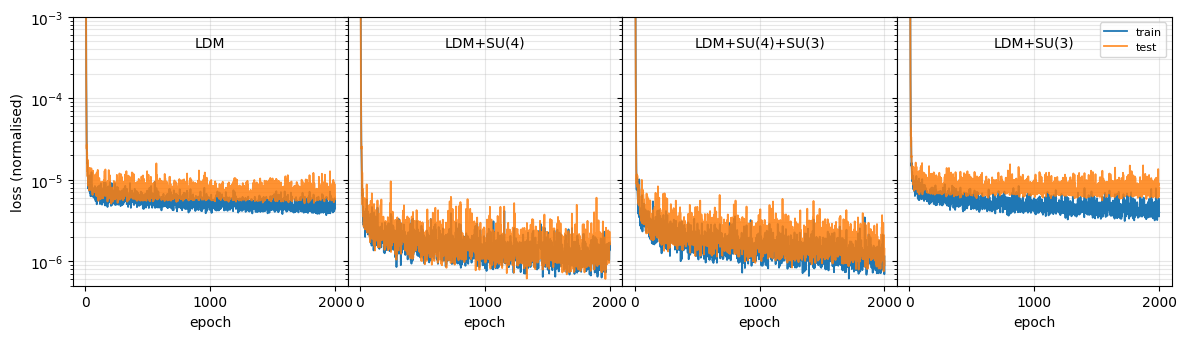

In [40]:
import os
os.makedirs('figures', exist_ok=True)

# Train vs test loss for the PINN (GK) models — one panel per feature set.
# Adjacent panels (shared y, no gap); title inside each panel; legend only on the last.
fig, axes = plt.subplots(1, len(FEATURE_SETS),
                         figsize=(12, 3.5),
                         sharey=True, squeeze=False)

last = len(FEATURE_SETS) - 1
for i, feat_name in enumerate(FEATURE_SETS):
    ax = axes[0, i]
    _, _, _, hist, _ = results[(feat_name, 'PINN')]
    tr_hist, te_hist = hist['train'], hist['test']
    ep = range(1, len(tr_hist) + 1)
    ax.semilogy(ep, tr_hist, lw=1.3, label='train')
    ax.semilogy(ep, te_hist, lw=1.3, label='test', alpha=0.85)

    # title inside the panel
    ax.text(0.5, 0.93, feat_name, transform=ax.transAxes,
            ha='center', va='top', fontsize=10)

    ax.set_xlabel('epoch')
    ax.set_ylim(5e-7, 1e-3)
    ax.grid(True, which='both', alpha=0.3)
    ax.locator_params(axis='x', nbins=4)   # fewer x ticks -> no boundary clash
    if i == 0:
        ax.set_ylabel('loss (normalised)')
    if i == last:
        ax.legend(fontsize=8, loc='upper right')

fig.tight_layout()
fig.subplots_adjust(wspace=0)               # collapse gaps -> panels touch
fig.savefig('figures/nn_loss_curves.png', dpi=200, bbox_inches='tight')
print('saved figures/nn_loss_curves.png')
plt.show()

## 9 — Prediction diagnostics

True-vs-predicted scatter and residual heatmap on the nuclear chart for each feature set.


--- LDM / PINN ---


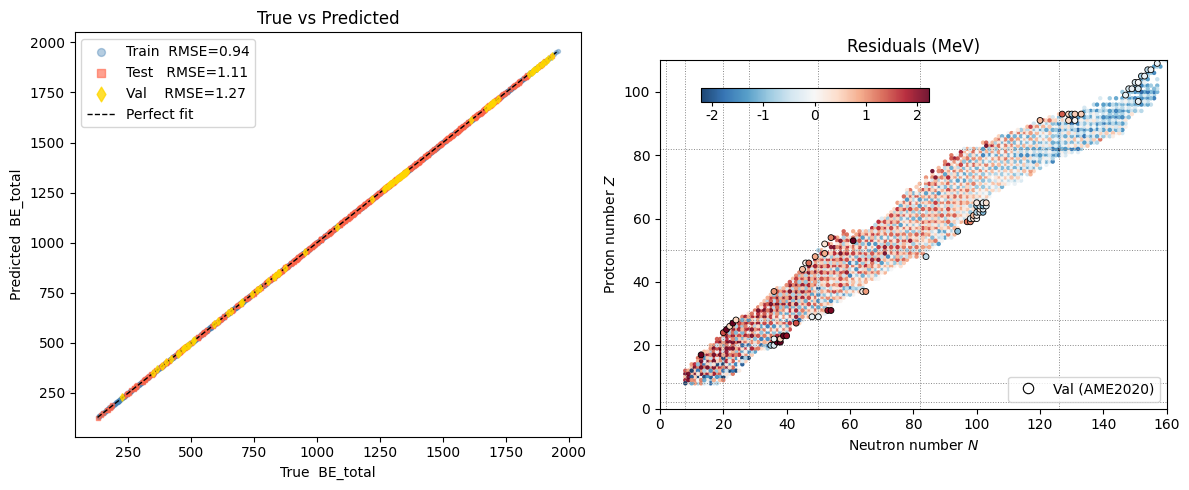


--- LDM+SU(4) / PINN ---


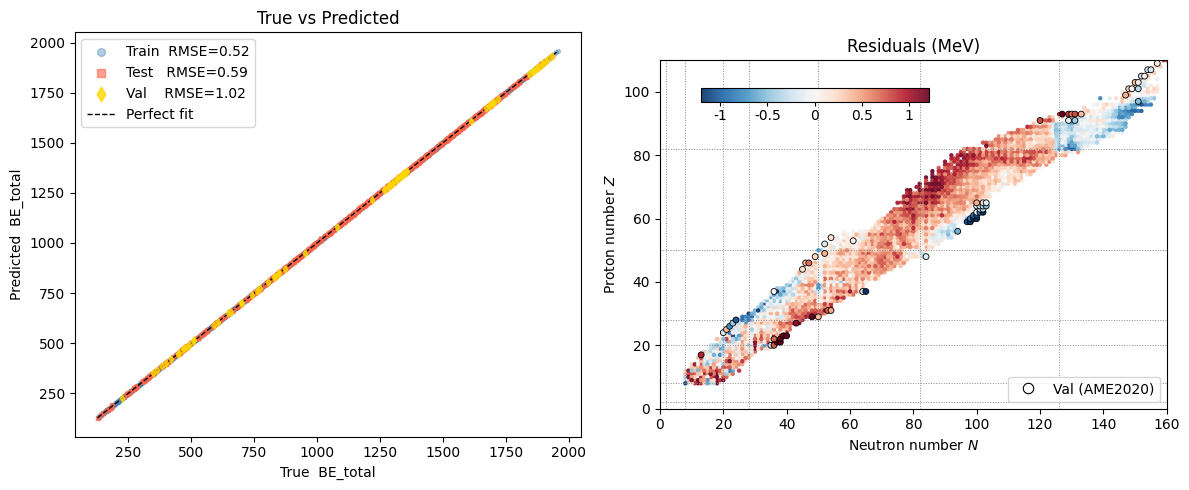


--- LDM+SU(4)+SU(3) / PINN ---


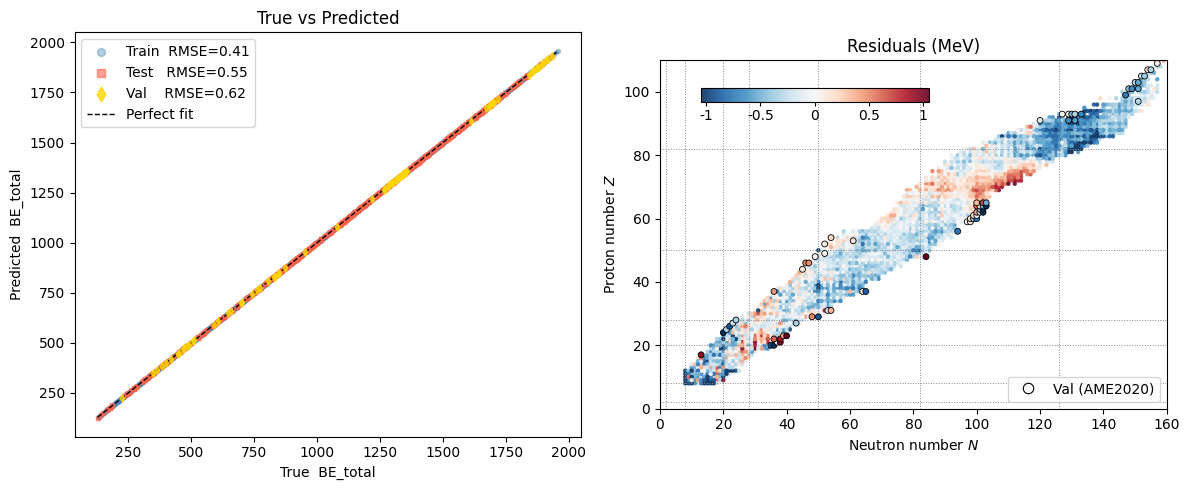


--- LDM+SU(3) / PINN ---


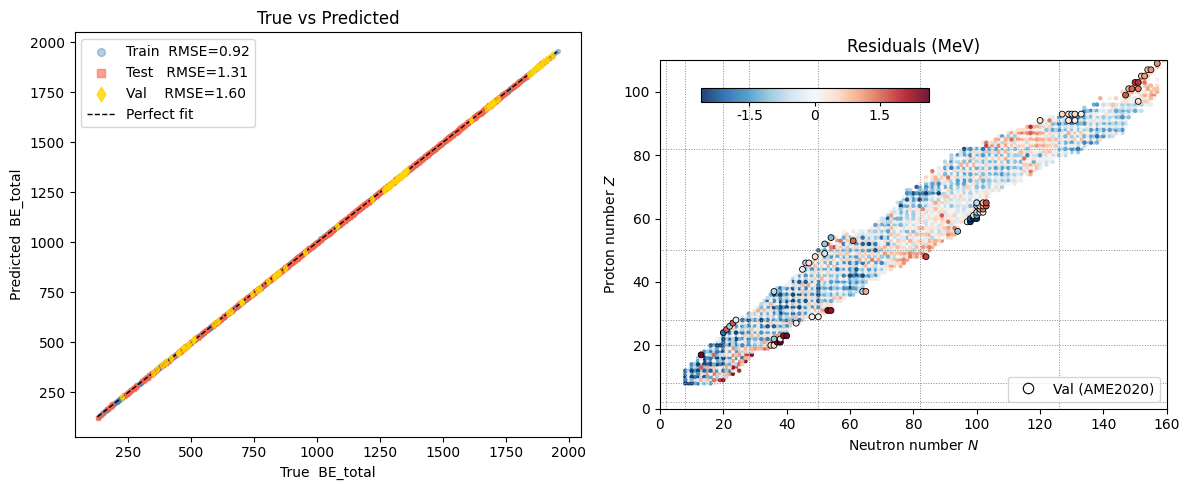

In [41]:
for feat_name in FEATURE_SETS:
    _, norm, metrics, _, tensors = results[(feat_name, 'PINN')]
    X_tr_, X_te_, X_v_, _, _, _ = tensors
    print(f'\n--- {feat_name} / PINN ---')
    symass.plot_predictions(
        metrics['train'], metrics['test'],
        tr_N=N_all[tr], tr_Z=Z_all[tr],
        te_N=N_all[te], te_Z=Z_all[te],
        val_metrics=metrics['val'],
        val_N=N_all[val], val_Z=Z_all[val],
    )

## 10 — SHAP feature importance

SHAP values quantify each feature's average contribution to the prediction.
Comparing the bar charts shows
which features the network actually uses and how importance redistributes
as the feature set grows.


--- SHAP: LDM ---


/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:593: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


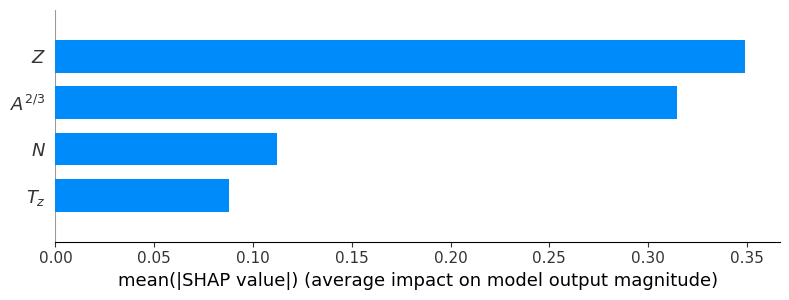

/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:605: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


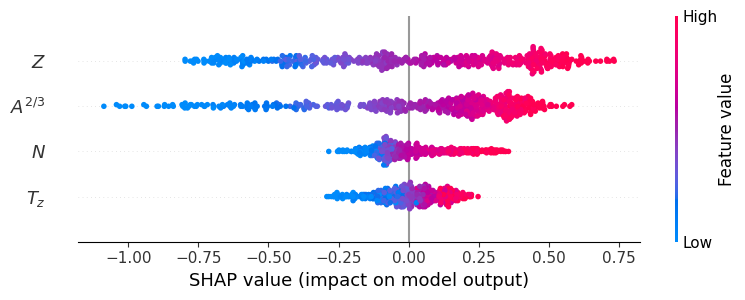


--- SHAP: LDM+SU(4) ---


/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:593: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


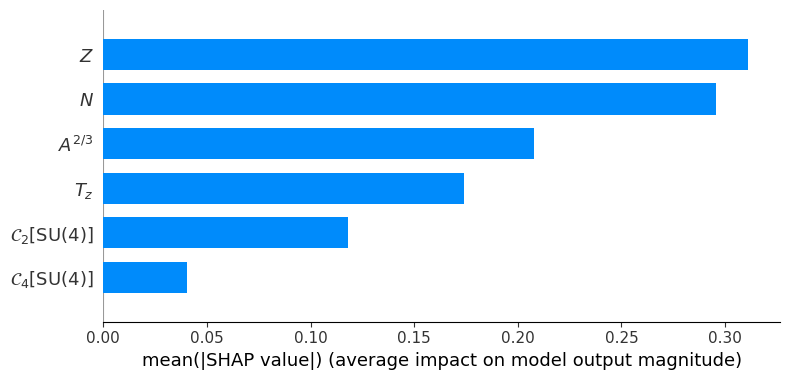

/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:605: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


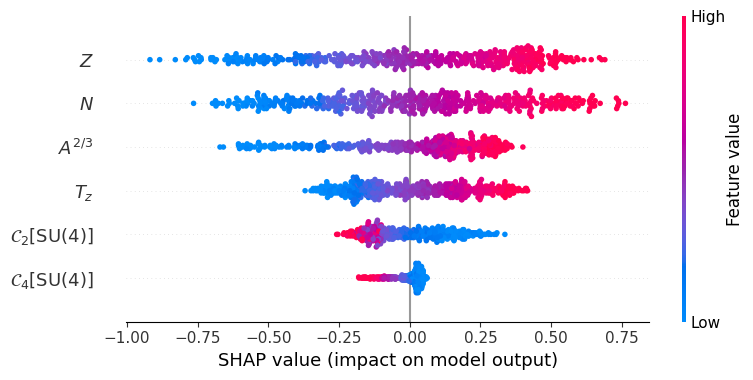


--- SHAP: LDM+SU(4)+SU(3) ---


/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:593: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


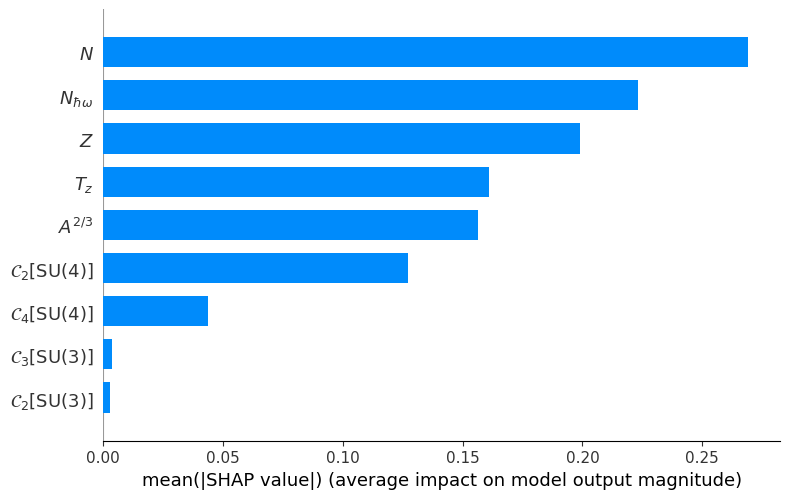

/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:605: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


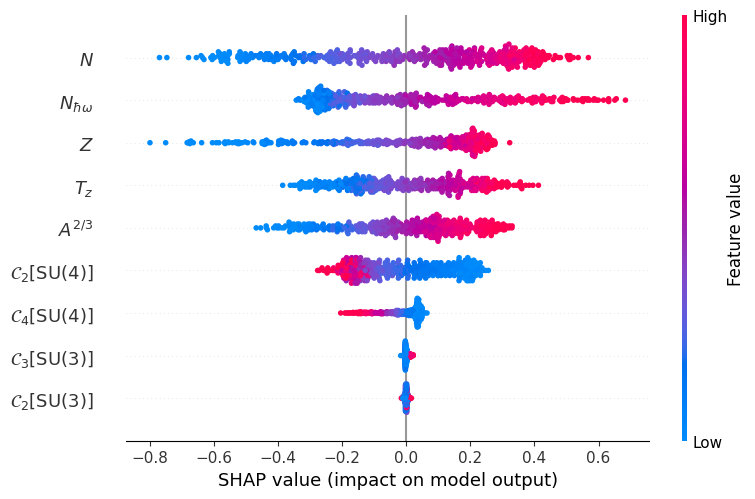


--- SHAP: LDM+SU(3) ---


/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:593: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


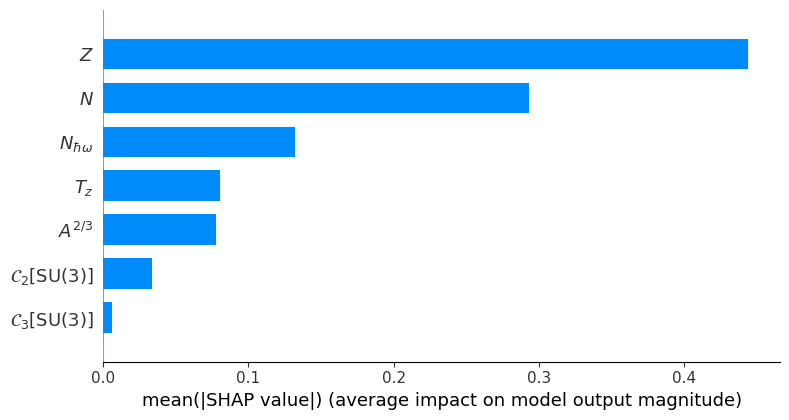

/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:605: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


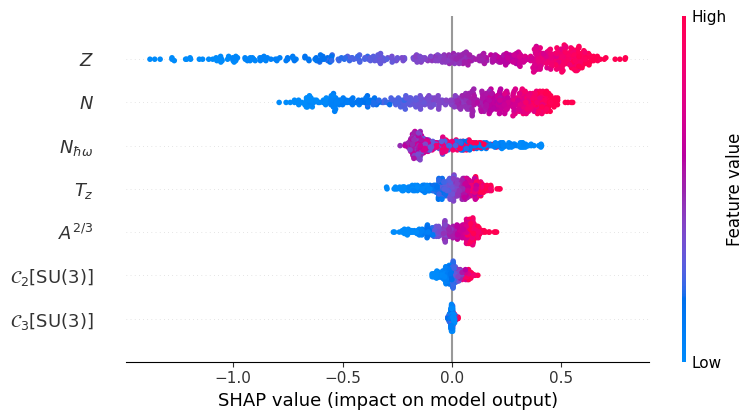

In [42]:
for feat_name in FEATURE_SETS:
    model, norm, _, _, tensors = results[(feat_name, 'PINN')]
    X_tr_, X_te_, *_ = tensors
    feats = FEATURE_SETS[feat_name]
    print(f'\n--- SHAP: {feat_name} ---')
    symass.plot_shap(model, X_tr_, X_te_, feats)